In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

Saving train_data_correct.csv to train_data_correct.csv
Loaded file: train_data_correct.csv


,OUT_CALLS,CALLS_CHARGE,SMS_MMS,SMS_MMS_CHARGE,GPRS_MB,GPRS_CHARGE,IDD_CALLS,IDD_CHARGE,ROAMING_CHARGE,OTHER_CHARGE,AGE,Gender,Churn
0,241.0,0.3999,19.0,10.2898,19668.0,0.0,0.0,0.0,0.0,89.9009,48.0,М,0
1,684.0,2.7777,27.0,2.4795,0.0,0.0,0.0,0.0,0.0,21.9353,33.0,М,0
2,765.0,8.6386,1.0,0.0899,0.0,0.0,0.0,0.0,0.0,39.0770,33.0,М,0
3,148.0,0.0000,62.0,18.7638,6086.0,0.0,0.0,0.0,0.0,307.5751,37.0,М,0
4,657.0,0.0000,0.0,0.0000,8588.0,0.0,0.0,0.0,0.0,100.0000,43.0,М,0


In [3]:
import sklearn, xgboost, lightgbm, joblib
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
xgboost: 3.2.0
lightgbm: 4.6.0
joblib: 1.5.3


In [4]:
print(df.shape)
print(df.columns.tolist())
print(df['Gender'].dtype)
print(df['Gender'].unique())

(110035, 13)
['OUT_CALLS', 'CALLS_CHARGE', 'SMS_MMS', 'SMS_MMS_CHARGE', 'GPRS_MB', 'GPRS_CHARGE', 'IDD_CALLS', 'IDD_CHARGE', 'ROAMING_CHARGE', 'OTHER_CHARGE', 'AGE', 'Gender', 'Churn']
object
['М' 'Ж' nan]


In [5]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())
print("\nChurn value counts:\n", df['Churn'].value_counts())
print("\nGender unique values:", df['Gender'].unique())

Shape: (110035, 13)

Dtypes:
 OUT_CALLS         float64
CALLS_CHARGE      float64
SMS_MMS           float64
SMS_MMS_CHARGE    float64
GPRS_MB           float64
GPRS_CHARGE       float64
IDD_CALLS         float64
IDD_CHARGE        float64
ROAMING_CHARGE    float64
OTHER_CHARGE      float64
AGE               float64
Gender             object
Churn               int64
dtype: object

Null counts:
 OUT_CALLS            6
CALLS_CHARGE         6
SMS_MMS              7
SMS_MMS_CHARGE       7
GPRS_MB              8
GPRS_CHARGE          8
IDD_CALLS           10
IDD_CHARGE          10
ROAMING_CHARGE      10
OTHER_CHARGE         0
AGE                  1
Gender            9518
Churn                0
dtype: int64

Describe:
            OUT_CALLS   CALLS_CHARGE        SMS_MMS  SMS_MMS_CHARGE  \
count  110029.000000  110029.000000  110028.000000   110028.000000   
mean      445.496049       6.556245      11.921811        2.337021   
std       647.939700      18.623261      53.825259        9.603228   

In [6]:
numeric_cols = ['OUT_CALLS', 'CALLS_CHARGE', 'SMS_MMS', 'SMS_MMS_CHARGE',
                'GPRS_MB', 'GPRS_CHARGE', 'IDD_CALLS', 'IDD_CHARGE',
                'ROAMING_CHARGE', 'OTHER_CHARGE', 'AGE']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in numeric_cols:
    df[col] = df[col].clip(lower=0)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (110035, 13)


In [7]:
unique_vals = df['Gender'].dropna().unique()
for v in unique_vals:
    print(repr(v), [hex(ord(c)) for c in str(v)])

'М' ['0x41c']
'Ж' ['0x416']


In [8]:
# Hardcoded by exact Unicode codepoint — NOT dependent on unique() order
# Confirmed via hex diagnostic: М = U+041C (male), Ж = U+0416 (female)
gender_map = {'\u041c': 1, '\u0416': 0}
df['Gender'] = df['Gender'].map(gender_map).fillna(-1).astype(int)
print(df['Gender'].value_counts())

Gender
 1    63081
 0    37436
-1     9518
Name: count, dtype: int64


In [9]:
df['total_spend'] = (df['CALLS_CHARGE'] + df['SMS_MMS_CHARGE'] +
                     df['GPRS_CHARGE'] + df['IDD_CHARGE'] +
                     df['ROAMING_CHARGE'] + df['OTHER_CHARGE'])

df['high_value_customer'] = (
    df['total_spend'] > df['total_spend'].quantile(0.75)
).astype(int)

df['high_data_user'] = (
    df['GPRS_MB'] > df['GPRS_MB'].quantile(0.75)
).astype(int)

df['is_idd_user'] = (df['IDD_CALLS'] > 0).astype(int)
df['is_roaming_user'] = (df['ROAMING_CHARGE'] > 0).astype(int)

df['spend_decrease_flag'] = (df['OUT_CALLS'] > 0) & (df['CALLS_CHARGE'] == 0)
df['spend_decrease_flag'] = df['spend_decrease_flag'].astype(int)

df['activity_drop_flag'] = (
    (df['OUT_CALLS'] == 0) &
    (df['SMS_MMS'] == 0) &
    (df['GPRS_MB'] == 0)
).astype(int)

df['active_services_count'] = (
    (df['OUT_CALLS'] > 0).astype(int) +
    (df['SMS_MMS'] > 0).astype(int) +
    (df['GPRS_MB'] > 0).astype(int) +
    (df['IDD_CALLS'] > 0).astype(int) +
    (df['ROAMING_CHARGE'] > 0).astype(int)
)
df['low_activity_flag'] = (df['active_services_count'] <= 1).astype(int)

df['age_band'] = pd.cut(
    df['AGE'],
    bins=[0, 25, 35, 50, 100],
    labels=[0, 1, 2, 3]
).cat.add_categories(-1).fillna(-1).astype(int)

df['usage_decrease_flag'] = (
    (df['GPRS_MB'] < df['GPRS_MB'].median()) &
    (df['SMS_MMS'] < df['SMS_MMS'].median())
).astype(int)

print("Feature engineering done. New shape:", df.shape)

Feature engineering done. New shape: (110035, 24)


In [10]:
numeric_features = [
    'OUT_CALLS', 'CALLS_CHARGE', 'SMS_MMS', 'SMS_MMS_CHARGE',
    'GPRS_MB', 'GPRS_CHARGE', 'IDD_CALLS', 'IDD_CHARGE',
    'ROAMING_CHARGE', 'OTHER_CHARGE', 'AGE',
    'total_spend', 'active_services_count'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
pipeline.fit(X_train)

print("✅ Final dataset shape:", df.shape)
print("✅ Training set:", X_train.shape)
print("✅ Test set:", X_test.shape)

✅ Final dataset shape: (110035, 24)
✅ Training set: (88028, 23)
✅ Test set: (22007, 23)


In [12]:
# Save fixed training-time thresholds for production use.
# These MUST be hardcoded in the FastAPI backend later — never
# recomputed from a newly uploaded file, since percentiles on a
# small batch are meaningless compared to the full training distribution.

TOTAL_SPEND_Q75 = X_train['total_spend'].quantile(0.75)
GPRS_MB_Q75 = X_train['GPRS_MB'].quantile(0.75)
GPRS_MB_MEDIAN = X_train['GPRS_MB'].median()
SMS_MMS_MEDIAN = X_train['SMS_MMS'].median()

print("TOTAL_SPEND_Q75 =", TOTAL_SPEND_Q75)
print("GPRS_MB_Q75 =", GPRS_MB_Q75)
print("GPRS_MB_MEDIAN =", GPRS_MB_MEDIAN)
print("SMS_MMS_MEDIAN =", SMS_MMS_MEDIAN)

import json
thresholds = {
    "total_spend_q75": float(TOTAL_SPEND_Q75),
    "gprs_mb_q75": float(GPRS_MB_Q75),
    "gprs_mb_median": float(GPRS_MB_MEDIAN),
    "sms_mms_median": float(SMS_MMS_MEDIAN)
}
with open('feature_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print("\n✅ Thresholds saved to feature_thresholds.json")

from google.colab import files
files.download('feature_thresholds.json')

TOTAL_SPEND_Q75 = 73.17439999999999
GPRS_MB_Q75 = 1421.0
GPRS_MB_MEDIAN = 3.0
SMS_MMS_MEDIAN = 0.0

✅ Thresholds saved to feature_thresholds.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
!pip install xgboost lightgbm --quiet

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

In [15]:
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed  = pipeline.transform(X_test)

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM':            LGBMClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    trained_models[name] = model
    print(f"✅ {name} trained")

✅ Logistic Regression trained
✅ Random Forest trained
✅ XGBoost trained
[LightGBM] [Info] Number of positive: 44028, number of negative: 44000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2551
[LightGBM] [Info] Number of data points in the train set: 88028, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500159 -> initscore=0.000636
[LightGBM] [Info] Start training from score 0.000636
✅ LightGBM trained


In [17]:
results = []

for name, model in trained_models.items():
    y_pred  = model.predict(X_test_transformed)
    y_proba = model.predict_proba(X_test_transformed)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            XGBoost    0.9355     0.9544  0.9148    0.9342   0.9814
           LightGBM    0.9314     0.9536  0.9070    0.9297   0.9789
      Random Forest    0.9283     0.9513  0.9030    0.9265   0.9765
Logistic Regression    0.8749     0.8783  0.8704    0.8743   0.9289


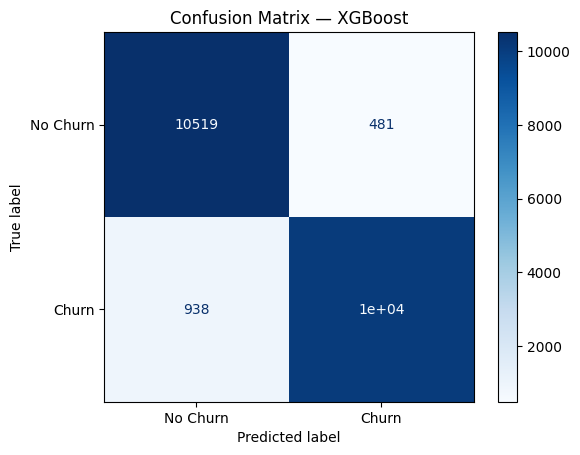


Best Model: XGBoost
              precision    recall  f1-score   support

    No Churn       0.92      0.96      0.94     11000
       Churn       0.95      0.91      0.93     11007

    accuracy                           0.94     22007
   macro avg       0.94      0.94      0.94     22007
weighted avg       0.94      0.94      0.94     22007



In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test_transformed)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

In [19]:
# Data Leakage Check
print("Features used for training:")
print(X_train.columns.tolist())

assert 'Churn' not in X_train.columns, "DATA LEAKAGE: Churn column found in features!"

leakage_suspects = [col for col in X_train.columns if 'churn' in col.lower()]
print("\nSuspected leakage columns:", leakage_suspects if leakage_suspects else "None ✅")

Features used for training:
['OUT_CALLS', 'CALLS_CHARGE', 'SMS_MMS', 'SMS_MMS_CHARGE', 'GPRS_MB', 'GPRS_CHARGE', 'IDD_CALLS', 'IDD_CHARGE', 'ROAMING_CHARGE', 'OTHER_CHARGE', 'AGE', 'Gender', 'total_spend', 'high_value_customer', 'high_data_user', 'is_idd_user', 'is_roaming_user', 'spend_decrease_flag', 'activity_drop_flag', 'active_services_count', 'low_activity_flag', 'age_band', 'usage_decrease_flag']

Suspected leakage columns: None ✅


In [20]:
# Subgroup check: does the model perform reliably for subscribers
# with missing Gender (-1)? This matters because future uploaded
# files may have a different proportion of missing Gender values
# than the training set did.

gender_test_values = X_test['Gender']

for gender_val, label in [(1, 'Male (1)'), (0, 'Female (0)'), (-1, 'Missing (-1)')]:
    mask = gender_test_values == gender_val
    if mask.sum() == 0:
        print(f"{label}: no rows in test set")
        continue

    y_test_sub = y_test[mask]
    y_pred_sub = best_model.predict(X_test_transformed[mask.values])
    y_proba_sub = best_model.predict_proba(X_test_transformed[mask.values])[:, 1]

    acc_sub = round(accuracy_score(y_test_sub, y_pred_sub), 4)
    roc_sub = round(roc_auc_score(y_test_sub, y_proba_sub), 4) if len(y_test_sub.unique()) > 1 else float('nan')

    print(f"{label}: n={mask.sum()}, Accuracy={acc_sub}, ROC-AUC={roc_sub}")

Male (1): n=12541, Accuracy=0.9349, ROC-AUC=0.9795
Female (0): n=7526, Accuracy=0.9273, ROC-AUC=0.978
Missing (-1): n=1940, Accuracy=0.9716, ROC-AUC=0.9887


Top 10 Most Important Features:
            Feature  Importance
          OUT_CALLS    0.511372
             Gender    0.083427
 activity_drop_flag    0.067199
                AGE    0.056139
       OTHER_CHARGE    0.033914
spend_decrease_flag    0.030955
        total_spend    0.030293
     SMS_MMS_CHARGE    0.029705
     ROAMING_CHARGE    0.025078
       CALLS_CHARGE    0.024349


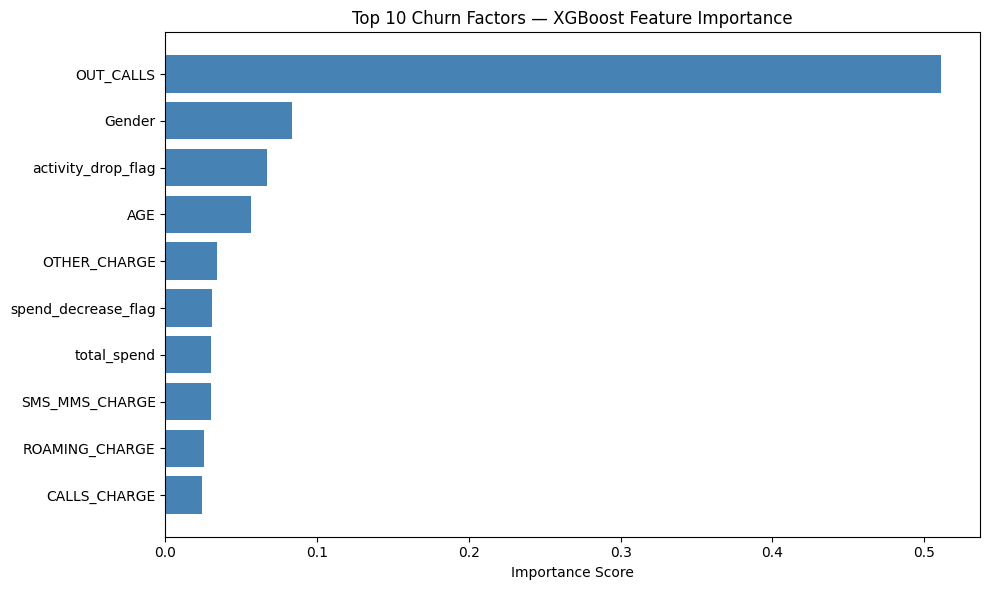

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Numeric features that go through the scaler (in exact order)
numeric_features_ordered = [
    'OUT_CALLS', 'CALLS_CHARGE', 'SMS_MMS', 'SMS_MMS_CHARGE',
    'GPRS_MB', 'GPRS_CHARGE', 'IDD_CALLS', 'IDD_CHARGE',
    'ROAMING_CHARGE', 'OTHER_CHARGE', 'AGE',
    'total_spend', 'active_services_count'
]

# Passthrough features (everything else, in their original order)
all_columns = X_train.columns.tolist()
passthrough_features = [col for col in all_columns if col not in numeric_features_ordered]

# Final correct feature order after ColumnTransformer
correct_feature_names = numeric_features_ordered + passthrough_features

# Build feature importance dataframe
feat_imp_df = pd.DataFrame({
    'Feature': correct_feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 Most Important Features:")
print(feat_imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Churn Factors — XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [22]:
# EXPERIMENT: Test model robustness without OUT_CALLS
# Checks if the model over-relies on a single feature

from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

X_train_no_calls = X_train.drop(columns=['OUT_CALLS'])
X_test_no_calls = X_test.drop(columns=['OUT_CALLS'])

numeric_features_no_calls = [f for f in numeric_features if f != 'OUT_CALLS']

numeric_transformer_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_no_calls = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_2, numeric_features_no_calls)
    ],
    remainder='passthrough'
)

X_train_t2 = preprocessor_no_calls.fit_transform(X_train_no_calls)
X_test_t2 = preprocessor_no_calls.transform(X_test_no_calls)

model_no_calls = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_no_calls.fit(X_train_t2, y_train)

y_pred_nc = model_no_calls.predict(X_test_t2)
y_proba_nc = model_no_calls.predict_proba(X_test_t2)[:, 1]

acc_nc = round(accuracy_score(y_test, y_pred_nc), 4)
roc_nc = round(roc_auc_score(y_test, y_proba_nc), 4)

acc_with = results_df[results_df['Model'] == best_model_name]['Accuracy'].values[0]
roc_with = results_df[results_df['Model'] == best_model_name]['ROC-AUC'].values[0]

print("=== Robustness Test: Without OUT_CALLS ===")
print(f"Accuracy: {acc_nc}")
print(f"ROC-AUC:  {roc_nc}")
print()
print(f"=== Original Model ({best_model_name}, with OUT_CALLS) ===")
print(f"Accuracy: {acc_with}")
print(f"ROC-AUC:  {roc_with}")
print()

drop = round((acc_with - acc_nc) * 100, 2)
print(f"Accuracy drop without OUT_CALLS: {drop}%")

if drop > 10:
    print("⚠️ Model heavily relies on OUT_CALLS")
elif drop > 5:
    print("⚠️ Moderate reliance on OUT_CALLS")
else:
    print("✅ Model is robust — other features contribute meaningfully")

=== Robustness Test: Without OUT_CALLS ===
Accuracy: 0.9103
ROC-AUC:  0.9682

=== Original Model (XGBoost, with OUT_CALLS) ===
Accuracy: 0.9355
ROC-AUC:  0.9814

Accuracy drop without OUT_CALLS: 2.52%
✅ Model is robust — other features contribute meaningfully


In [23]:
full_churn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

full_churn_pipeline.fit(X_train, y_train)

joblib.dump(full_churn_pipeline, 'full_churn_pipeline.pkl')
print("✅ Full end-to-end pipeline saved as full_churn_pipeline.pkl")

from google.colab import files
files.download('full_churn_pipeline.pkl')

✅ Full end-to-end pipeline saved as full_churn_pipeline.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>